In [21]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix
df=pd.read_csv("Social_media_impact_on_life.csv")
df.head()



,Student_ID,Age,Gender,Academic_Level,Primary_Platform,Daily_Usage_Hours,Weekend_Extra_Hours,Device_Type,Sleep_Duration_Hours,Sleep_Quality_Score,Late_Night_Usage,Social_Comparison_Frequency,Perceived_Stress_Score,Mental_Health_Index,Academic_Performance_GPA,Overall_Impact
0,STU_2024000,19,Female,Undergraduate,Snapchat,7.5,1.5,Smartphone,5.9,2,True,Always,20.0,73,2.73,Neutral
1,STU_2024001,19,Female,Undergraduate,Instagram,4.6,1.3,Smartphone,7.9,3,True,Sometimes,17.0,90,3.21,Beneficial
2,STU_2024002,17,Female,High School,TikTok,10.9,1.7,Smartphone,5.2,1,True,Frequently,18.0,70,3.00,Neutral
3,STU_2024003,16,Female,High School,YouTube,6.0,2.3,Tablet,7.6,4,True,Sometimes,15.0,82,3.42,Beneficial
4,STU_2024004,17,Male,High School,LinkedIn,3.3,2.6,Smartphone,7.6,4,True,Never,16.0,84,3.41,Beneficial


In [11]:
df["Perceived_Stress_Score"]=df["Perceived_Stress_Score"].fillna(df["Perceived_Stress_Score"].mean())
df["Academic_Performance_GPA"]=df["Academic_Performance_GPA"].fillna(df["Academic_Performance_GPA"].mean())
df=df.drop(["Student_ID"],axis=1)
df=pd.get_dummies(df,columns=["Gender","Academic_Level","Primary_Platform","Device_Type","Social_Comparison_Frequency"],drop_first=True)
df["Late_Night_Usage"]=df["Late_Night_Usage"].astype(int)
df.head()

,Age,Daily_Usage_Hours,Weekend_Extra_Hours,Sleep_Duration_Hours,Sleep_Quality_Score,Late_Night_Usage,Perceived_Stress_Score,Mental_Health_Index,Academic_Performance_GPA,Overall_Impact,...,Primary_Platform_Snapchat,Primary_Platform_TikTok,Primary_Platform_X (Twitter),Primary_Platform_YouTube,Device_Type_Smartphone,Device_Type_Tablet,Social_Comparison_Frequency_Frequently,Social_Comparison_Frequency_Never,Social_Comparison_Frequency_Rarely,Social_Comparison_Frequency_Sometimes
0,19,7.5,1.5,5.9,2,1,20.0,73,2.73,Neutral,...,True,False,False,False,True,False,False,False,False,False
1,19,4.6,1.3,7.9,3,1,17.0,90,3.21,Beneficial,...,False,False,False,False,True,False,False,False,False,True
2,17,10.9,1.7,5.2,1,1,18.0,70,3.00,Neutral,...,False,True,False,False,True,False,True,False,False,False
3,16,6.0,2.3,7.6,4,1,15.0,82,3.42,Beneficial,...,False,False,False,True,False,True,False,False,False,True
4,17,3.3,2.6,7.6,4,1,16.0,84,3.41,Beneficial,...,False,False,False,False,True,False,False,True,False,False


In [13]:
x=df.drop("Overall_Impact",axis=1)
y=df["Overall_Impact"]
print("Features:")
print(x.columns)

print("\nTarget:")
print(y.value_counts())

Features:
Index(['Age', 'Daily_Usage_Hours', 'Weekend_Extra_Hours',
       'Sleep_Duration_Hours', 'Sleep_Quality_Score', 'Late_Night_Usage',
       'Perceived_Stress_Score', 'Mental_Health_Index',
       'Academic_Performance_GPA', 'Gender_Male', 'Gender_Non-Binary',
       'Gender_Prefer not to say', 'Academic_Level_Postgraduate',
       'Academic_Level_Undergraduate', 'Primary_Platform_LinkedIn',
       'Primary_Platform_Reddit', 'Primary_Platform_Snapchat',
       'Primary_Platform_TikTok', 'Primary_Platform_X (Twitter)',
       'Primary_Platform_YouTube', 'Device_Type_Smartphone',
       'Device_Type_Tablet', 'Social_Comparison_Frequency_Frequently',
       'Social_Comparison_Frequency_Never',
       'Social_Comparison_Frequency_Rarely',
       'Social_Comparison_Frequency_Sometimes'],
      dtype='str')

Target:
Overall_Impact
Beneficial    3681
Neutral        654
Negative       165
Name: count, dtype: int64


In [23]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
scaler=StandardScaler()
xtrain_scaled=scaler.fit_transform(X_train)
xtest_scaled=scaler.transform(X_test)
logistic_model=LogisticRegression(max_iter=1000)
logistic_model.fit(xtrain_scaled,y_train)
logistic_pred=logistic_model.predict(xtest_scaled)
accuracyL=accuracy_score(y_test,logistic_pred)
precisionL=precision_score(y_test,logistic_pred,average="weighted")
recallL=recall_score(y_test,logistic_pred,average="weighted")
f1L=f1_score(y_test,logistic_pred,average="weighted")
print("Logistic Regression")
print("Accuracy:", accuracyL)
print("Precision:", precisionL)
print("Recall:",recallL)
print("F1 Score:",f1L)

Logistic Regression
Accuracy: 0.9811111111111112
Precision: 0.9809943685868483
Recall: 0.9811111111111112
F1 Score: 0.9810412361381653


In [24]:
# Create KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(xtrain_scaled, y_train)
knn_pred = knn_model.predict(xtest_scaled)
knn_accuracy = accuracy_score(y_test, knn_pred)
knn_precision = precision_score(y_test, knn_pred, average="weighted", zero_division=0)
knn_recall = recall_score(y_test, knn_pred, average="weighted", zero_division=0)
knn_f1 = f1_score(y_test, knn_pred, average="weighted", zero_division=0)
print("KNN")
print("Accuracy:", knn_accuracy)
print("Precision:", knn_precision)
print("Recall:", knn_recall)
print("F1 Score:", knn_f1)

KNN
Accuracy: 0.9211111111111111
Precision: 0.916847420535183
Recall: 0.9211111111111111
F1 Score: 0.9145472154053013


In [25]:
## Decision tree model
decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train, y_train)
decision_tree_pred = decision_tree_model.predict(X_test)
decision_tree_accuracy = accuracy_score(y_test, decision_tree_pred)
decision_tree_precision = precision_score(y_test, decision_tree_pred, average="weighted", zero_division=0)
decision_tree_recall = recall_score(y_test, decision_tree_pred, average="weighted", zero_division=0)
decision_tree_f1 = f1_score(y_test, decision_tree_pred, average="weighted", zero_division=0)
print("Decision Tree")
print("Accuracy:", decision_tree_accuracy)
print("Precision:", decision_tree_precision)
print("Recall:", decision_tree_recall)
print("F1 Score:", decision_tree_f1)

Decision Tree
Accuracy: 0.9666666666666667
Precision: 0.96790233363046
Recall: 0.9666666666666667
F1 Score: 0.9671380282605208


In [26]:
# Create Gaussian Naive Bayes model
naive_bayes_model = GaussianNB()
naive_bayes_model.fit(xtrain_scaled, y_train)
naive_bayes_pred = naive_bayes_model.predict(xtest_scaled)
naive_bayes_accuracy = accuracy_score(y_test, naive_bayes_pred)
naive_bayes_precision = precision_score(y_test, naive_bayes_pred, average="weighted", zero_division=0)
naive_bayes_recall = recall_score(y_test, naive_bayes_pred, average="weighted", zero_division=0)
naive_bayes_f1 = f1_score(y_test, naive_bayes_pred, average="weighted", zero_division=0)
print("Gaussian Naive Bayes")
print("Accuracy:", naive_bayes_accuracy)
print("Precision:", naive_bayes_precision)
print("Recall:", naive_bayes_recall)
print("F1 Score:", naive_bayes_f1)

Gaussian Naive Bayes
Accuracy: 0.9266666666666666
Precision: 0.9383084764484068
Recall: 0.9266666666666666
F1 Score: 0.9304763506748369


In [29]:
results = pd.DataFrame({"Model": ["Logistic Regression", "KNN", "Decision Tree", "Gaussian Naive Bayes"], "Accuracy": [accuracyL, knn_accuracy, decision_tree_accuracy, naive_bayes_accuracy], "Precision": [precisionL, knn_precision, decision_tree_precision, naive_bayes_precision], "Recall": [recallL, knn_recall, decision_tree_recall, naive_bayes_recall], "F1 Score": [f1L, knn_f1, decision_tree_f1, naive_bayes_f1]})

print(results)
best_model = results.loc[results["F1 Score"].idxmax()]
print("Best Model:")
print(best_model)

                  Model  Accuracy  Precision    Recall  F1 Score
0   Logistic Regression  0.981111   0.980994  0.981111  0.981041
1                   KNN  0.921111   0.916847  0.921111  0.914547
2         Decision Tree  0.966667   0.967902  0.966667  0.967138
3  Gaussian Naive Bayes  0.926667   0.938308  0.926667  0.930476
Best Model:
Model        Logistic Regression
Accuracy                0.981111
Precision               0.980994
Recall                  0.981111
F1 Score                0.981041
Name: 0, dtype: object


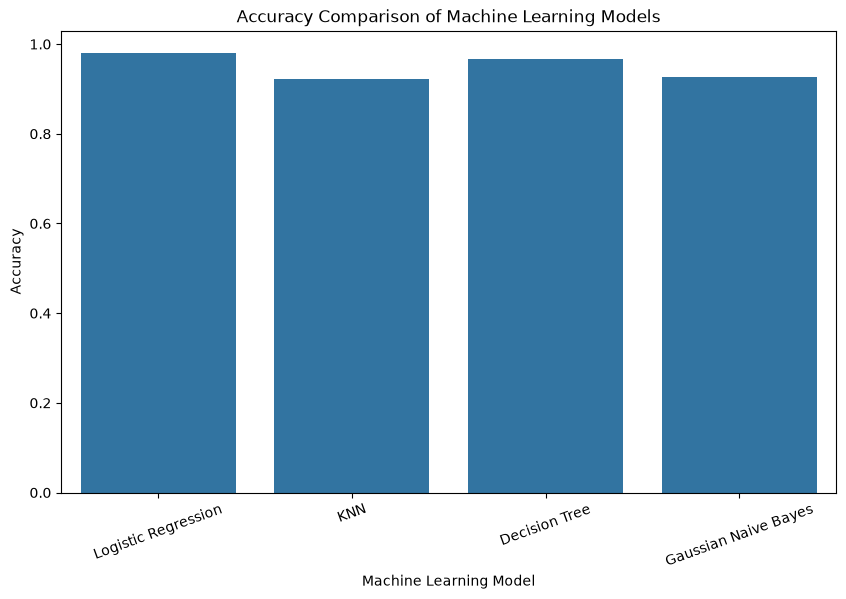

In [30]:
plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="Accuracy", data=results)
plt.title("Accuracy Comparison of Machine Learning Models")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()

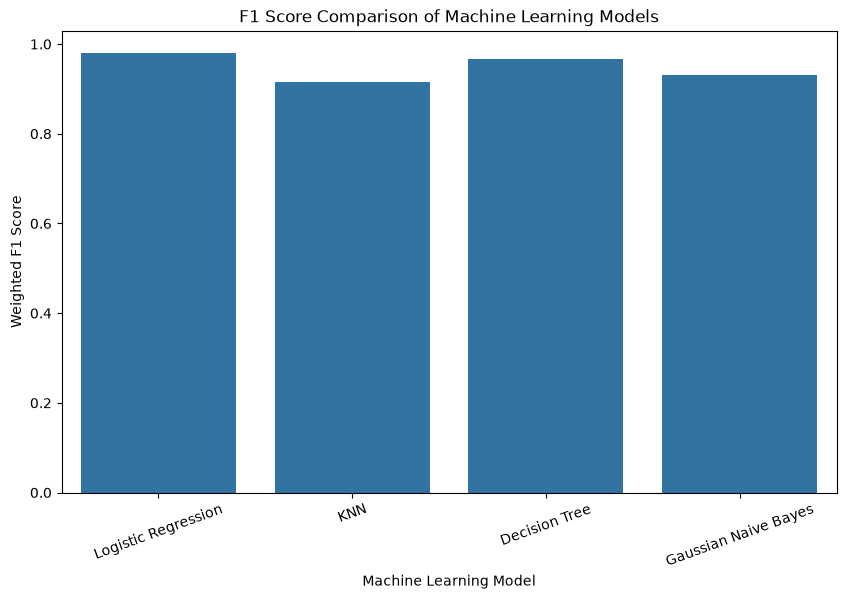

In [31]:
plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="F1 Score", data=results)
plt.title("F1 Score Comparison of Machine Learning Models")
plt.xlabel("Machine Learning Model")
plt.ylabel("Weighted F1 Score")
plt.xticks(rotation=20)
plt.show()

In [32]:
predictions = {"Logistic Regression": logistic_pred, "KNN": knn_pred, "Decision Tree": decision_tree_pred, "Gaussian Naive Bayes": naive_bayes_pred}
best_model_name = results.loc[results["F1 Score"].idxmax(), "Model"]
best_prediction = predictions[best_model_name]
print("Best Model:", best_model_name)
print(classification_report(y_test, best_prediction, zero_division=0))

Best Model: Logistic Regression
              precision    recall  f1-score   support

  Beneficial       0.99      0.99      0.99       736
    Negative       0.94      0.91      0.92        33
     Neutral       0.94      0.93      0.93       131

    accuracy                           0.98       900
   macro avg       0.96      0.94      0.95       900
weighted avg       0.98      0.98      0.98       900



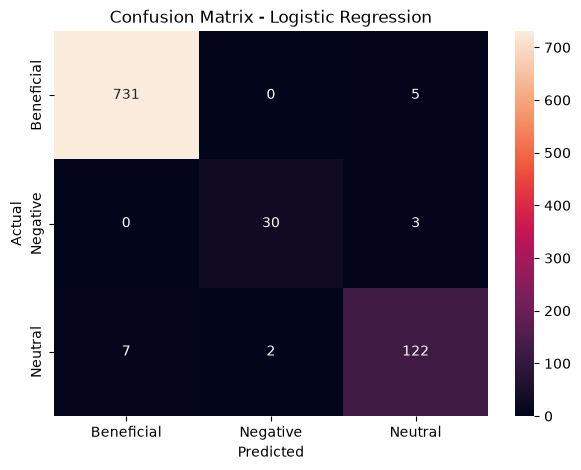

In [33]:
cm = confusion_matrix(y_test, best_prediction)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()))
plt.title("Confusion Matrix - " + best_model_name)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()